# Ensemble of Ordinal Models — Advanced Strategies

This notebook extends the baseline ensemble with advanced combination strategies:

1. **Median** — Robust central tendency (less sensitive to outlier models)
2. **Geometric Mean** — Product of probabilities in log-space (rewards agreement)
3. **Confidence-Weighted** — Weight each model by its prediction confidence (low entropy = high weight)
4. **Rank Averaging** — Average predicted ordinal ranks across models
5. **Borda Count** — Rank-based voting (Condorcet aggregation)
6. **Trimmed Mean** — Mean after discarding the most extreme probability per position
7. **Softmax-Temperature** — Soft voting with learnable temperature calibration

Same model set as the baseline ensemble:
- **B3-Entropy-Ordinal-Focal**
- **B0-Entropy-Ordinal-Focal**
- **B7-Entropy-Ordinal-Focal**

In [1]:
from torchvision.models import efficientnet_b0, efficientnet_b7, efficientnet_b3, convnext_small
from torchvision.models import EfficientNet_B0_Weights, EfficientNet_B3_Weights, EfficientNet_B7_Weights, ConvNeXt_Small_Weights
import torch
import random
import numpy as np
import torch.nn as nn
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, recall_score, precision_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys
sys.path.append('../../..')
from utils.dataset import PandasDataset
from utils.models import EfficientNetApi, ConvNeXtApi

## Configuration

In [2]:
seed = 42
batch_size = 3
num_workers = 4
output_classes = 5  # Ordinal thresholds
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set seeds
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Paths
ROOT_DIR = '../../..'
data_dir = '../../../..'
images_dir = os.path.join(data_dir, 'tiles')

os.makedirs('logs', exist_ok=True)

Using device: cuda


## Ordinal Prediction Utilities

In [3]:
def decode_ordinal_predictions(logits):
    """
    Convert ordinal logits to class labels.
    Applies sigmoid then counts probabilities > 0.5.
    """
    probs = torch.sigmoid(logits)
    return (probs > 0.5).sum(dim=1)


def grade_to_ordinal_logits(grades, num_classes, device):
    """
    Convert a 1-D integer grade tensor back to fake ordinal logits
    (used by voting methods that need to return logits for compatibility).
    """
    batch_size = grades.shape[0]
    logits = torch.zeros(batch_size, num_classes, device=device)
    for i in range(batch_size):
        grade = int(grades[i].item())
        if grade > 0:
            logits[i, :grade] = 10.0
        if grade < num_classes:
            logits[i, grade:] = -10.0
    return logits


print("Ordinal utilities loaded")

Ordinal utilities loaded


## Load Pre-trained Ordinal Models

In [4]:
# Model 1: B3 Entropy-Ordinal-Focal
print("Loading Model 1: B3 Entropy-Ordinal-Focal...")
load_model_1 = efficientnet_b3(weights=EfficientNet_B3_Weights.DEFAULT)
model_1 = EfficientNetApi(model=load_model_1, output_dimensions=output_classes, dropout_rate=0.6)
model_1.load_state_dict(torch.load("models/b3-entropy-ordinal-focal.pth", weights_only=True))
model_1 = model_1.to(device)
model_1.eval()
print("✓ Loaded B3 Entropy-Ordinal-Focal")

# Model 2: B0 Entropy-Ordinal-Focal
print("\nLoading Model 2: B0 Entropy-Ordinal-Focal...")
load_model_2 = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model_2 = EfficientNetApi(model=load_model_2, output_dimensions=output_classes, dropout_rate=0.6)
model_2.load_state_dict(torch.load("models/b0-entropy-ordinal-3-focal.pth", weights_only=True))
model_2 = model_2.to(device)
model_2.eval()
print("✓ Loaded B0 Entropy-Ordinal-Focal")


# Model 4: B7 Entropy-Ordinal-Focal
print("\nLoading Model 3: B7 Entropy-Ordinal-Focal...")
load_model_4 = efficientnet_b7(weights=EfficientNet_B7_Weights.DEFAULT)
model_4 = EfficientNetApi(model=load_model_4, output_dimensions=output_classes, dropout_rate=0.6)
model_4.load_state_dict(torch.load("models/b7-entropy-ordinal-focal.pth", weights_only=True))
model_4 = model_4.to(device)
model_4.eval()
print("✓ Loaded B7 Entropy-Ordinal-Focal")


# Model ConvNeXt Small
print("\nLoading Model ConvNeXt Small...")
load_model_conv = convnext_small(weights=ConvNeXt_Small_Weights.DEFAULT)
model_conv = ConvNeXtApi(model=load_model_conv, output_dimensions=output_classes, dropout_rate=0.6)
model_conv.load_state_dict(torch.load("models/convnext_small.pth", weights_only=True))
model_conv = model_conv.to(device)
model_conv.eval()
print("✓ Loaded ConvNeXt Small")

models_list = [model_1, model_2, model_4, model_conv]
model_names = [
    "B3-Entropy-Ordinal-Focal",
    "B0-Entropy-Ordinal-Focal",
    "B7-Entropy-Ordinal-Focal",
    "ConvNeXt-Small",
]

print(f"\n{'='*80}")
print(f"Total models loaded: {len(models_list)}")
print(f"{'='*80}")

Loading Model 1: B3 Entropy-Ordinal-Focal...
✓ Loaded B3 Entropy-Ordinal-Focal

Loading Model 2: B0 Entropy-Ordinal-Focal...
✓ Loaded B0 Entropy-Ordinal-Focal

Loading Model 3: B7 Entropy-Ordinal-Focal...
✓ Loaded B7 Entropy-Ordinal-Focal

Loading Model ConvNeXt Small...
✓ Loaded ConvNeXt Small

Total models loaded: 4


## Load Test Dataset

In [5]:
df_test = pd.read_csv(f"{ROOT_DIR}/data/test.csv")

def remove_nonexistent_images(df, images_dir):
    image_ids = df['image_id'].apply(lambda x: os.path.join(images_dir, f"{x}.png"))
    existent_images = [os.path.isfile(path) for path in image_ids]
    return df[existent_images]

df_test = remove_nonexistent_images(df_test, images_dir)
print(f"Test samples: {len(df_test)}")

test_dataset = PandasDataset(images_dir, df_test, transforms=None, format="png")
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False,
)
print(f"Test batches: {len(test_loader)}")

Test samples: 1590
Test batches: 530


## Advanced Ensemble Class

In [6]:
class AdvancedOrdinalEnsemble(nn.Module):
    """
    Advanced ensemble for ordinal regression models.

    Supported methods
    -----------------
    Baseline (for comparison)
      mean           : Simple average of sigmoid probabilities
      weighted_mean  : Fixed-weight average of probabilities
      max            : Per-position maximum probability
      majority_vote  : Hard voting on decoded grades

    Advanced
      median         : Per-position median probability (robust to outlier models)
      geometric_mean : Geometric mean of probabilities (log-space average)
      conf_weighted  : Weight each model by its per-sample confidence
                       (confidence = 1 - normalised binary entropy of its probs)
      rank_avg       : Average predicted ordinal grade then round
      borda_count    : Borda count over ordinal grades (rank-based aggregation)
      trimmed_mean   : Mean after removing the single highest/lowest probability
                       per threshold position (requires >= 3 models)
      softmax_temp   : Soft voting after scaling logits by a temperature T
                       (temperature passed as `temp` kwarg, default 1.0)
    """

    def __init__(self, models, method='mean', weights=None, temp=1.0):
        super().__init__()
        self.models = nn.ModuleList(models)
        self.method = method
        self.temp = temp
        self.num_classes = None  # inferred at first forward

        if method == 'weighted_mean' and weights is not None:
            w = torch.tensor(weights, dtype=torch.float32)
            self.weights = w / w.sum()
            print(f"Normalised weights: {self.weights.tolist()}")
        else:
            self.weights = None

    # ------------------------------------------------------------------
    # helpers
    # ------------------------------------------------------------------
    @staticmethod
    def _binary_entropy(p):
        """Per-element binary entropy H(p) = -p*log(p) - (1-p)*log(1-p)."""
        eps = 1e-7
        p = p.clamp(eps, 1 - eps)
        return -(p * p.log() + (1 - p) * (1 - p).log())

    @staticmethod
    def _to_logits(probs):
        return torch.logit(probs.clamp(1e-7, 1 - 1e-7))

    def _decode(self, logits):
        return (torch.sigmoid(logits) > 0.5).sum(dim=1)

    # ------------------------------------------------------------------
    # forward
    # ------------------------------------------------------------------
    def forward(self, x):
        with torch.no_grad():
            raw = torch.stack([m(x) for m in self.models])  # (M, B, C)

        M, B, C = raw.shape
        self.num_classes = C
        probs = torch.sigmoid(raw)  # (M, B, C)

        # ---------- baseline methods ----------
        if self.method == 'mean':
            return self._to_logits(probs.mean(dim=0))

        elif self.method == 'weighted_mean':
            w = self.weights.to(x.device).view(M, 1, 1)
            return self._to_logits((probs * w).sum(dim=0))

        elif self.method == 'max':
            return self._to_logits(probs.max(dim=0)[0])

        elif self.method == 'majority_vote':
            grades = torch.stack([self._decode(raw[m]) for m in range(M)])  # (M, B)
            voted = grades.mode(dim=0)[0]  # (B,)
            return grade_to_ordinal_logits(voted, C, x.device)

        # ---------- advanced methods ----------
        elif self.method == 'median':
            # Median across models for each threshold position
            median_probs = probs.median(dim=0)[0]  # (B, C)
            return self._to_logits(median_probs)

        elif self.method == 'geometric_mean':
            # Geometric mean: exp(mean(log(p)))
            log_probs = probs.clamp(1e-7, 1 - 1e-7).log()  # (M, B, C)
            geo_mean = log_probs.mean(dim=0).exp()           # (B, C)
            # Re-normalise so values stay in (0,1) after geometric compression
            geo_mean = geo_mean.clamp(1e-7, 1 - 1e-7)
            return self._to_logits(geo_mean)

        elif self.method == 'conf_weighted':
            # Per-sample confidence weight: 1 - mean binary entropy (higher = more certain)
            # entropy shape: (M, B, C)  ->  mean over C -> (M, B)
            H = self._binary_entropy(probs).mean(dim=2)        # (M, B)
            conf = (1.0 - H / np.log(2))                       # normalise to [0,1]
            conf = conf.clamp(min=1e-7)                        # avoid zero weights
            # Normalise weights per sample: (M, B) -> (M, B, 1)
            w = conf / conf.sum(dim=0, keepdim=True)           # (M, B)
            w = w.unsqueeze(2)                                  # (M, B, 1)
            ensemble_probs = (probs * w).sum(dim=0)            # (B, C)
            return self._to_logits(ensemble_probs)

        elif self.method == 'rank_avg':
            # Decode each model to a grade, average, and round
            grades = torch.stack([self._decode(raw[m]).float() for m in range(M)])  # (M, B)
            avg_grade = grades.mean(dim=0).round().long().clamp(0, C)               # (B,)
            return grade_to_ordinal_logits(avg_grade, C, x.device)

        elif self.method == 'borda_count':
            # Borda count: assign score = (max_grade - predicted_grade) to each model,
            # sum scores across models, pick the grade with the max total score.
            # For ordinal regression with C+1 grades (0..C), treat grade g as
            # receiving C - g points in a "lower is better" competition — we want
            # the grade that minimises total rank distance to all models.
            grades = torch.stack([self._decode(raw[m]) for m in range(M)])  # (M, B)  values in 0..C
            max_grade = C  # maximum possible grade
            # Accumulate Borda scores: score[g] = sum_m (max_grade - |grade_m - g|)
            # Equivalently: minimise total absolute deviation -> median grade
            # (Borda in ordinal space is equivalent to L1 median)
            scores = torch.zeros(B, max_grade + 1, device=x.device)
            for g in range(max_grade + 1):
                # deviation of each model from grade g: (M, B)
                dev = (grades.float() - g).abs()
                scores[:, g] = -(dev.sum(dim=0))  # negate: max score = least deviation
            borda_grade = scores.argmax(dim=1).long()  # (B,)
            return grade_to_ordinal_logits(borda_grade, C, x.device)

        elif self.method == 'trimmed_mean':
            # Remove the single most extreme (highest and lowest) probability
            # per threshold position, then average the rest.
            # Requires at least 3 models; falls back to mean otherwise.
            if M < 3:
                return self._to_logits(probs.mean(dim=0))
            # sort along model axis
            sorted_probs, _ = probs.sort(dim=0)       # (M, B, C)
            trimmed = sorted_probs[1:-1]              # remove min and max model -> (M-2, B, C)
            return self._to_logits(trimmed.mean(dim=0))

        elif self.method == 'softmax_temp':
            # Scale logits by 1/T before sigmoid, then average probabilities
            scaled = raw / self.temp                  # (M, B, C)
            scaled_probs = torch.sigmoid(scaled)      # (M, B, C)
            return self._to_logits(scaled_probs.mean(dim=0))

        else:
            raise ValueError(f"Unknown ensemble method: {self.method}")


print("AdvancedOrdinalEnsemble class defined")

AdvancedOrdinalEnsemble class defined


## Evaluation Functions

In [7]:
def evaluate_model(model, dataloader, device, model_name="Model"):
    model.eval()
    all_preds, all_targets, all_img_ids = [], [], []

    with torch.no_grad():
        for batch_data, batch_targets, img_id in tqdm(dataloader, desc=f"Evaluating {model_name}"):
            batch_data = batch_data.to(device)
            logits = model(batch_data)
            predictions = decode_ordinal_predictions(logits)
            targets_class = batch_targets.sum(dim=1).long()
            all_preds.append(predictions.cpu())
            all_targets.append(targets_class)
            all_img_ids.extend(img_id)

    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()

    return {
        'predictions': all_preds,
        'targets': all_targets,
        'img_ids': all_img_ids,
        'accuracy': accuracy_score(all_targets, all_preds),
        'kappa': cohen_kappa_score(all_targets, all_preds, weights='quadratic'),
        'f1': f1_score(all_targets, all_preds, average='macro', zero_division=0),
        'recall': recall_score(all_targets, all_preds, average='macro', zero_division=0),
        'precision': precision_score(all_targets, all_preds, average='macro', zero_division=0),
    }


def print_metrics(metrics, model_name):
    print(f"\n{'='*80}")
    print(f"{model_name} — TEST RESULTS")
    print(f"{'='*80}")
    print(f"Accuracy:  {metrics['accuracy']*100:.2f}%")
    print(f"Kappa:     {metrics['kappa']:.4f}")
    print(f"F1:        {metrics['f1']:.4f}")
    print(f"Recall:    {metrics['recall']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"{'='*80}")


print("Evaluation functions defined")

Evaluation functions defined


## Evaluate Individual Models

In [8]:
print("\n" + "="*80)
print("INDIVIDUAL MODEL PERFORMANCE")
print("="*80)

individual_results = {}
for model, name in zip(models_list, model_names):
    metrics = evaluate_model(model, test_loader, device, name)
    individual_results[name] = metrics
    print_metrics(metrics, name)


INDIVIDUAL MODEL PERFORMANCE


Evaluating B3-Entropy-Ordinal-Focal: 100%|██████████| 530/530 [02:36<00:00,  3.38it/s]



B3-Entropy-Ordinal-Focal — TEST RESULTS
Accuracy:  65.97%
Kappa:     0.8484
F1:        0.6188
Recall:    0.6169
Precision: 0.6243


Evaluating B0-Entropy-Ordinal-Focal: 100%|██████████| 530/530 [01:29<00:00,  5.92it/s]



B0-Entropy-Ordinal-Focal — TEST RESULTS
Accuracy:  68.05%
Kappa:     0.8589
F1:        0.6167
Recall:    0.6130
Precision: 0.6279


Evaluating B7-Entropy-Ordinal-Focal: 100%|██████████| 530/530 [07:45<00:00,  1.14it/s]



B7-Entropy-Ordinal-Focal — TEST RESULTS
Accuracy:  60.25%
Kappa:     0.8440
F1:        0.5564
Recall:    0.5550
Precision: 0.5610


Evaluating ConvNeXt-Small: 100%|██████████| 530/530 [05:20<00:00,  1.65it/s]


ConvNeXt-Small — TEST RESULTS
Accuracy:  50.82%
Kappa:     0.7473
F1:        0.4473
Recall:    0.4480
Precision: 0.4490


In [9]:
base_name = model_names[0]
oracle_df = pd.DataFrame({
    'img_id': individual_results[base_name]['img_ids'],
    'true_label': individual_results[base_name]['targets'],
})
col_names = ['b3', 'b0', 'b7', 'convnext']
for col, name in zip(col_names, model_names):
    oracle_df[col] = individual_results[name]['predictions']

print(oracle_df.head(10))
print(f"Shape: {oracle_df.shape}")

                             img_id  true_label  b3  b0  b7  convnext
0  5ad2c7349c24ed5c4901522bec9d3077           0   0   0   0         0
1  96bb7ad81bef9aa7ce0280d7b49b6476           4   4   3   4         5
2  cb9bc923249b183c8fc5b904f622695e           2   2   3   3         3
3  f7af5eef3236461e745cd8b81f1cf93b           1   1   1   1         0
4  f35124ad7e0c9d8537a8e57966c06445           0   0   0   0         0
5  93c9f7f98f8ecda60b56a601eccc5acc           4   4   5   4         4
6  20c05ea5426b6c50b857057ad0ef7126           2   1   2   2         3
7  6f5722cf3b8e5a90dc1e0eff127c4632           0   0   0   0         0
8  3202735e79f54cef6981c1b481f18859           1   2   1   0         0
9  632a836af7b82fc1351e5e6955a33c9c           1   1   1   1         1
Shape: (1590, 6)


## Baseline Ensemble Methods (reference)
Included for direct comparison in the final table.

In [ ]:
baseline_configs = [
    ('mean',          dict()),
    ('weighted_mean', dict(weights=[0.2, 0.5, 0.2, 0.1])),
    ('max',           dict()),
    ('majority_vote', dict()),
]

baseline_results = {}
for method, kwargs in baseline_configs:
    label = f"Baseline-{method.replace('_', '-').title()}"
    print(f"\n{label}")
    ens = AdvancedOrdinalEnsemble(models_list, method=method, **kwargs).to(device)
    metrics = evaluate_model(ens, test_loader, device, label)
    baseline_results[label] = metrics
    print_metrics(metrics, label)


Baseline-Mean


Evaluating Baseline-Mean: 100%|██████████| 530/530 [16:21<00:00,  1.85s/it]



Baseline-Mean — TEST RESULTS
Accuracy:  70.31%
Kappa:     0.8739
F1:        0.6505
Recall:    0.6449
Precision: 0.6618

Baseline-Weighted-Mean
Normalised weights: [0.27272728085517883, 0.27272728085517883, 0.45454543828964233]


Evaluating Baseline-Weighted-Mean:   0%|          | 0/530 [00:02<?, ?it/s]


RuntimeError: shape '[4, 1, 1]' is invalid for input of size 3

## Advanced Ensemble Methods

### 1. Median

In [ ]:
print("\n" + "="*80)
print("ENSEMBLE: MEDIAN")
print("="*80)
print("Uses the per-position median probability across models.")
print("More robust than mean to a single poorly-calibrated model.")

ens_median = AdvancedOrdinalEnsemble(models_list, method='median').to(device)
metrics_median = evaluate_model(ens_median, test_loader, device, "Ensemble-Median")
print_metrics(metrics_median, "Ensemble-Median")


ENSEMBLE: MEDIAN
Uses the per-position median probability across models.
More robust than mean to a single poorly-calibrated model.


Evaluating Ensemble-Median: 100%|██████████| 530/530 [10:19<00:00,  1.17s/it]


Ensemble-Median — TEST RESULTS
Accuracy:  69.43%
Kappa:     0.8693
F1:        0.6486
Recall:    0.6448
Precision: 0.6566


### 2. Geometric Mean

In [ ]:
print("\n" + "="*80)
print("ENSEMBLE: GEOMETRIC MEAN")
print("="*80)
print("Averages log-probabilities, then exponentiates.")
print("Only yields a high combined probability when ALL models agree.")

ens_geo = AdvancedOrdinalEnsemble(models_list, method='geometric_mean').to(device)
metrics_geo = evaluate_model(ens_geo, test_loader, device, "Ensemble-GeomMean")
print_metrics(metrics_geo, "Ensemble-GeomMean")


ENSEMBLE: GEOMETRIC MEAN
Averages log-probabilities, then exponentiates.
Only yields a high combined probability when ALL models agree.


Evaluating Ensemble-GeomMean: 100%|██████████| 530/530 [10:17<00:00,  1.16s/it]


Ensemble-GeomMean — TEST RESULTS
Accuracy:  71.38%
Kappa:     0.8690
F1:        0.6591
Recall:    0.6526
Precision: 0.6766


### 3. Confidence-Weighted

In [ ]:
print("\n" + "="*80)
print("ENSEMBLE: CONFIDENCE-WEIGHTED")
print("="*80)
print("Each model's weight is proportional to its per-sample confidence.")
print("Confidence = 1 - normalised mean binary entropy of ordinal probabilities.")
print("A model that is more certain about a sample contributes more to that sample's prediction.")

ens_conf = AdvancedOrdinalEnsemble(models_list, method='conf_weighted').to(device)
metrics_conf = evaluate_model(ens_conf, test_loader, device, "Ensemble-ConfWeighted")
print_metrics(metrics_conf, "Ensemble-ConfWeighted")


ENSEMBLE: CONFIDENCE-WEIGHTED
Each model's weight is proportional to its per-sample confidence.
Confidence = 1 - normalised mean binary entropy of ordinal probabilities.
A model that is more certain about a sample contributes more to that sample's prediction.


Evaluating Ensemble-ConfWeighted: 100%|██████████| 530/530 [10:15<00:00,  1.16s/it]


Ensemble-ConfWeighted — TEST RESULTS
Accuracy:  71.51%
Kappa:     0.8691
F1:        0.6618
Recall:    0.6572
Precision: 0.6741


### 4. Rank Averaging

In [ ]:
print("\n" + "="*80)
print("ENSEMBLE: RANK AVERAGING")
print("="*80)
print("Each model decodes its logits to an ISUP grade, then grades are averaged and rounded.")
print("Directly exploits the ordinal structure of the output space.")

ens_rank = AdvancedOrdinalEnsemble(models_list, method='rank_avg').to(device)
metrics_rank = evaluate_model(ens_rank, test_loader, device, "Ensemble-RankAvg")
print_metrics(metrics_rank, "Ensemble-RankAvg")


ENSEMBLE: RANK AVERAGING
Each model decodes its logits to an ISUP grade, then grades are averaged and rounded.
Directly exploits the ordinal structure of the output space.


Evaluating Ensemble-RankAvg: 100%|██████████| 530/530 [10:16<00:00,  1.16s/it]


Ensemble-RankAvg — TEST RESULTS
Accuracy:  67.61%
Kappa:     0.8741
F1:        0.6303
Recall:    0.6260
Precision: 0.6403


### 5. Borda Count

In [ ]:
print("\n" + "="*80)
print("ENSEMBLE: BORDA COUNT")
print("="*80)
print("Selects the grade that minimises the total absolute deviation across model predictions.")
print("Equivalent to the L1-median of predicted grades (robust to outlier predictions).")

ens_borda = AdvancedOrdinalEnsemble(models_list, method='borda_count').to(device)
metrics_borda = evaluate_model(ens_borda, test_loader, device, "Ensemble-BordaCount")
print_metrics(metrics_borda, "Ensemble-BordaCount")


ENSEMBLE: BORDA COUNT
Selects the grade that minimises the total absolute deviation across model predictions.
Equivalent to the L1-median of predicted grades (robust to outlier predictions).


Evaluating Ensemble-BordaCount: 100%|██████████| 530/530 [10:15<00:00,  1.16s/it]


Ensemble-BordaCount — TEST RESULTS
Accuracy:  69.31%
Kappa:     0.8693
F1:        0.6469
Recall:    0.6430
Precision: 0.6553


### 6. Trimmed Mean

In [ ]:
print("\n" + "="*80)
print("ENSEMBLE: TRIMMED MEAN")
print("="*80)
print("Removes the most extreme model probability for each threshold position,")
print("then averages the remaining models. (Requires >= 3 models.)")

ens_trim = AdvancedOrdinalEnsemble(models_list, method='trimmed_mean').to(device)
metrics_trim = evaluate_model(ens_trim, test_loader, device, "Ensemble-TrimmedMean")
print_metrics(metrics_trim, "Ensemble-TrimmedMean")


ENSEMBLE: TRIMMED MEAN
Removes the most extreme model probability for each threshold position,
then averages the remaining models. (Requires >= 3 models.)


Evaluating Ensemble-TrimmedMean: 100%|██████████| 530/530 [10:15<00:00,  1.16s/it]


Ensemble-TrimmedMean — TEST RESULTS
Accuracy:  69.43%
Kappa:     0.8693
F1:        0.6486
Recall:    0.6448
Precision: 0.6566


### 7. Softmax-Temperature (T = 0.5)

In [ ]:
print("\n" + "="*80)
print("ENSEMBLE: SOFTMAX-TEMPERATURE  T=0.5 (sharper)")
print("="*80)
print("Scales logits by 1/T before applying sigmoid.")
print("T < 1 sharpens each model's distribution; T > 1 softens it.")

ens_temp05 = AdvancedOrdinalEnsemble(models_list, method='softmax_temp', temp=0.5).to(device)
metrics_temp05 = evaluate_model(ens_temp05, test_loader, device, "Ensemble-Temp0.5")
print_metrics(metrics_temp05, "Ensemble-Temp0.5")


ENSEMBLE: SOFTMAX-TEMPERATURE  T=0.5 (sharper)
Scales logits by 1/T before applying sigmoid.
T < 1 sharpens each model's distribution; T > 1 softens it.


Evaluating Ensemble-Temp0.5: 100%|██████████| 530/530 [10:14<00:00,  1.16s/it]


Ensemble-Temp0.5 — TEST RESULTS
Accuracy:  70.94%
Kappa:     0.8728
F1:        0.6594
Recall:    0.6545
Precision: 0.6714


In [ ]:
print("\n" + "="*80)
print("ENSEMBLE: SOFTMAX-TEMPERATURE  T=2.0 (softer)")
print("="*80)

ens_temp20 = AdvancedOrdinalEnsemble(models_list, method='softmax_temp', temp=2.0).to(device)
metrics_temp20 = evaluate_model(ens_temp20, test_loader, device, "Ensemble-Temp2.0")
print_metrics(metrics_temp20, "Ensemble-Temp2.0")


ENSEMBLE: SOFTMAX-TEMPERATURE  T=2.0 (softer)


Evaluating Ensemble-Temp2.0: 100%|██████████| 530/530 [10:15<00:00,  1.16s/it]


Ensemble-Temp2.0 — TEST RESULTS
Accuracy:  71.26%
Kappa:     0.8750
F1:        0.6600
Recall:    0.6550
Precision: 0.6724


## Results Comparison

In [ ]:
advanced_results = {
    'Ensemble-Median':       metrics_median,
    'Ensemble-GeomMean':     metrics_geo,
    'Ensemble-ConfWeighted': metrics_conf,
    'Ensemble-RankAvg':      metrics_rank,
    'Ensemble-BordaCount':   metrics_borda,
    'Ensemble-TrimmedMean':  metrics_trim,
    'Ensemble-Temp0.5':      metrics_temp05,
    'Ensemble-Temp2.0':      metrics_temp20,
}

all_results = {**individual_results, **baseline_results, **advanced_results}

sorted_results = sorted(all_results.items(), key=lambda x: x[1]['kappa'], reverse=True)

print("\n" + "="*110)
print("COMPLETE RESULTS COMPARISON (sorted by Quadratic Weighted Kappa)")
print("="*110)
print(f"{'Model':<45} {'Accuracy':>12} {'Kappa':>10} {'F1':>10} {'Recall':>10} {'Precision':>10}")
print("-"*110)
for name, m in sorted_results:
    print(f"{name:<45} {m['accuracy']*100:>11.2f}% {m['kappa']:>10.4f} {m['f1']:>10.4f} {m['recall']:>10.4f} {m['precision']:>10.4f}")
print("="*110)

best_model = sorted_results[0][0]
best_kappa = sorted_results[0][1]['kappa']
print(f"\n✓ Best model: {best_model}  (Kappa: {best_kappa:.4f})")


COMPLETE RESULTS COMPARISON (sorted by Quadratic Weighted Kappa)
Model                                             Accuracy      Kappa         F1     Recall  Precision
--------------------------------------------------------------------------------------------------------------
Baseline-Mean                                       71.26%     0.8752     0.6615     0.6565     0.6744
Ensemble-Temp2.0                                    71.26%     0.8750     0.6600     0.6550     0.6724
Baseline-Weighted-Mean                              71.45%     0.8747     0.6626     0.6580     0.6740
Ensemble-RankAvg                                    67.61%     0.8741     0.6303     0.6260     0.6403
Ensemble-Temp0.5                                    70.94%     0.8728     0.6594     0.6545     0.6714
Ensemble-BordaCount                                 69.31%     0.8693     0.6469     0.6430     0.6553
Ensemble-Median                                     69.43%     0.8693     0.6486     0.6448     0.6566

## Visualisation — Kappa Scores

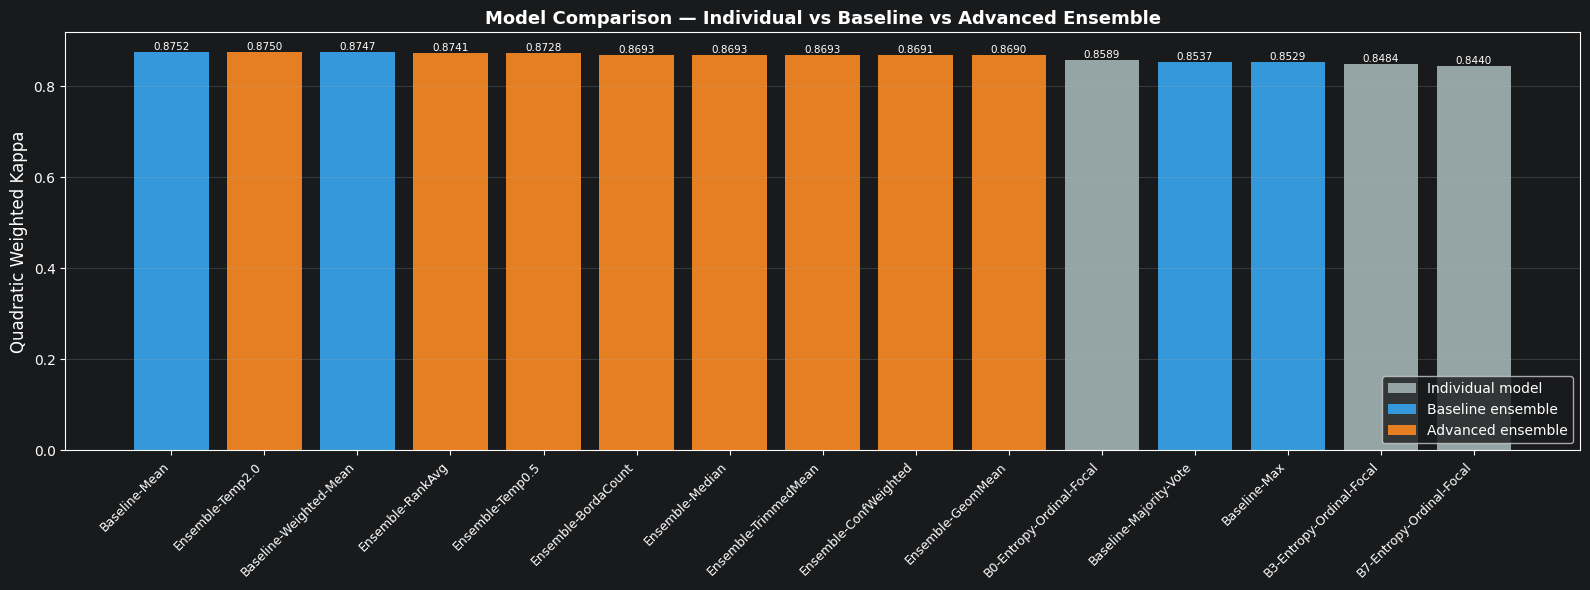

In [ ]:
names   = [name for name, _ in sorted_results]
kappas  = [m['kappa'] for _, m in sorted_results]

# Colour scheme: individual=grey, baseline=blue, advanced=orange
def _color(name):
    if name in individual_results:
        return '#95a5a6'
    if name in baseline_results:
        return '#3498db'
    return '#e67e22'

colors = [_color(n) for n in names]

fig, ax = plt.subplots(figsize=(16, 6))
bars = ax.bar(range(len(names)), kappas, color=colors)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Quadratic Weighted Kappa', fontsize=12)
ax.set_title('Model Comparison — Individual vs Baseline vs Advanced Ensemble', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar, k in zip(bars, kappas):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{k:.4f}', ha='center', va='bottom', fontsize=7.5)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#95a5a6', label='Individual model'),
    Patch(facecolor='#3498db', label='Baseline ensemble'),
    Patch(facecolor='#e67e22', label='Advanced ensemble'),
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('logs/ensemble-advanced-comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Confusion Matrix — Best Ensemble

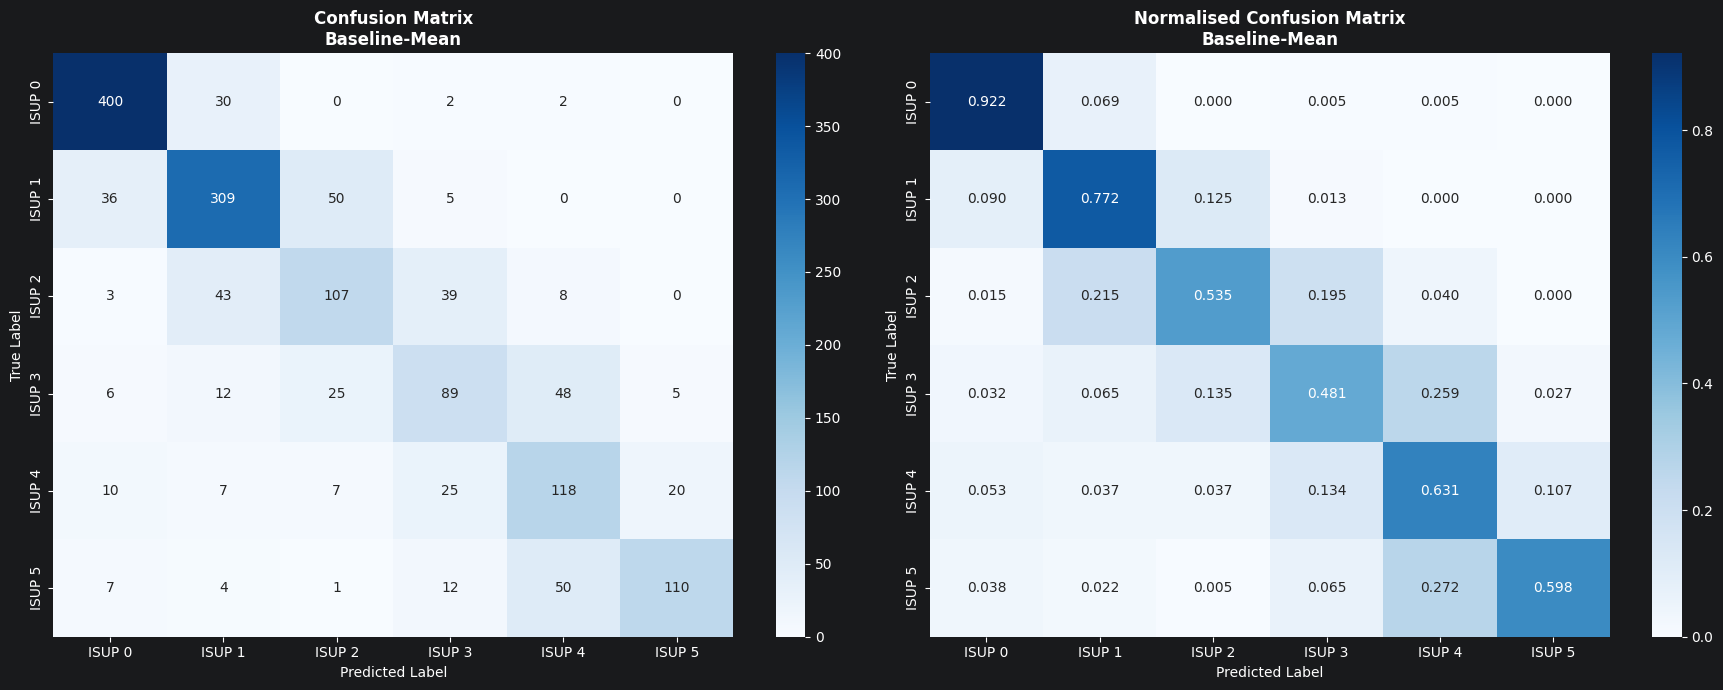

In [ ]:
best_metrics   = sorted_results[0][1]
predictions    = best_metrics['predictions']
targets        = best_metrics['targets']
cm             = confusion_matrix(targets, predictions)
cm_norm        = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

labels = [f'ISUP {i}' for i in range(6)]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title(f'Confusion Matrix\n{best_model}', fontweight='bold')
axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title(f'Normalised Confusion Matrix\n{best_model}', fontweight='bold')
axes[1].set_ylabel('True Label'); axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('logs/ensemble-advanced-confusion-matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## Classification Report — Best Ensemble

In [ ]:
print(f"Classification Report — {best_model}")
print("="*80)
print(classification_report(
    targets, predictions,
    target_names=[f'ISUP {i}' for i in range(6)],
    digits=4, zero_division=0,
))

Classification Report — Baseline-Mean
              precision    recall  f1-score   support

      ISUP 0     0.8658    0.9217    0.8929       434
      ISUP 1     0.7630    0.7725    0.7677       400
      ISUP 2     0.5632    0.5350    0.5487       200
      ISUP 3     0.5174    0.4811    0.4986       185
      ISUP 4     0.5221    0.6310    0.5714       187
      ISUP 5     0.8148    0.5978    0.6897       184

    accuracy                         0.7126      1590
   macro avg     0.6744    0.6565    0.6615      1590
weighted avg     0.7150    0.7126    0.7109      1590



## Statistical Analysis with 95% Confidence Intervals (Bootstrap)

In [ ]:
def calculate_confidence_intervals(targets, predictions, n_iterations=1000, confidence=0.95):
    stats = {k: [] for k in ['Accuracy', 'Kappa', 'F1-Score', 'Recall', 'Precision']}
    alpha = (1.0 - confidence) * 100 / 2.0
    for _ in range(n_iterations):
        idx = resample(range(len(targets)), n_samples=len(targets))
        t = np.array(targets)[idx]
        p = np.array(predictions)[idx]
        stats['Accuracy'].append(accuracy_score(t, p))
        stats['Kappa'].append(cohen_kappa_score(t, p, weights='quadratic'))
        stats['F1-Score'].append(f1_score(t, p, average='macro', zero_division=0))
        stats['Recall'].append(recall_score(t, p, average='macro', zero_division=0))
        stats['Precision'].append(precision_score(t, p, average='macro', zero_division=0))

    return {
        metric: {
            'mean':  np.mean(v),
            'std':   np.std(v),
            'lower': np.percentile(v, alpha),
            'upper': np.percentile(v, 100 - alpha),
        }
        for metric, v in stats.items()
    }


print("Bootstrap CI function defined")

Bootstrap CI function defined


In [ ]:
print("\n" + "="*100)
print("STATISTICAL ANALYSIS — 95% CONFIDENCE INTERVALS (1000 Bootstrap Iterations)")
print("="*100)

all_model_stats = []
for model_name, metrics in all_results.items():
    print(f"  Processing {model_name}...")
    stats = calculate_confidence_intervals(metrics['targets'], metrics['predictions'])
    all_model_stats.append((model_name, stats))

all_model_stats.sort(key=lambda x: x[1]['Kappa']['mean'], reverse=True)

print("\n" + "="*100)
print("SUMMARY — Sorted by Mean Kappa")
print("="*100)
print(f"{'Model':<45} {'Kappa (Mean)':<14} {'Std Dev':<10} {'95% CI'}")
print("-"*100)
for name, s in all_model_stats:
    k = s['Kappa']
    print(f"{name:<45} {k['mean']:<14.4f} {k['std']:<10.4f} [{k['lower']:.4f}, {k['upper']:.4f}]")

with open('logs/ensemble-advanced-stats.txt', 'w') as f:
    f.write("Advanced Ensemble — Statistical Analysis (1000 Bootstrap Iterations)\n")
    f.write("="*80 + "\n\n")
    for name, s in all_model_stats:
        f.write(f"Model: {name}\n")
        f.write(f"{'Metric':<15} {'Mean':<10} {'Std Dev':<10} {'95% CI Lower':<15} {'95% CI Upper'}\n")
        for metric, v in s.items():
            f.write(f"{metric:<15} {v['mean']:.4f}     {v['std']:.4f}     {v['lower']:.4f}          {v['upper']:.4f}\n")
        f.write("\n" + "-"*80 + "\n\n")

print("\n✓ Saved to logs/ensemble-advanced-stats.txt")


STATISTICAL ANALYSIS — 95% CONFIDENCE INTERVALS (1000 Bootstrap Iterations)
  Processing B3-Entropy-Ordinal-Focal...
  Processing B0-Entropy-Ordinal-Focal...
  Processing B7-Entropy-Ordinal-Focal...
  Processing Baseline-Mean...
  Processing Baseline-Weighted-Mean...
  Processing Baseline-Max...
  Processing Baseline-Majority-Vote...
  Processing Ensemble-Median...
  Processing Ensemble-GeomMean...
  Processing Ensemble-ConfWeighted...
  Processing Ensemble-RankAvg...
  Processing Ensemble-BordaCount...
  Processing Ensemble-TrimmedMean...
  Processing Ensemble-Temp0.5...
  Processing Ensemble-Temp2.0...

SUMMARY — Sorted by Mean Kappa
Model                                         Kappa (Mean)   Std Dev    95% CI
----------------------------------------------------------------------------------------------------
Baseline-Mean                                 0.8748         0.0109     [0.8522, 0.8945]
Ensemble-Temp2.0                              0.8745         0.0107     [0.8529, 0.895

## Save Full Results

In [ ]:
oracle_df['ensemble_median']       = metrics_median['predictions']
oracle_df['ensemble_geom']         = metrics_geo['predictions']
oracle_df['ensemble_conf']         = metrics_conf['predictions']
oracle_df['ensemble_rank_avg']     = metrics_rank['predictions']
oracle_df['ensemble_borda']        = metrics_borda['predictions']
oracle_df['ensemble_trimmed']      = metrics_trim['predictions']
oracle_df['ensemble_temp05']       = metrics_temp05['predictions']
oracle_df['ensemble_temp20']       = metrics_temp20['predictions']
oracle_df.to_csv('logs/oracle_advanced_ensemble.csv', index=False)
print("✓ Oracle dataframe saved to logs/oracle_advanced_ensemble.csv")

with open('logs/ensemble-advanced-results.txt', 'w') as f:
    f.write("Advanced Ensemble of Ordinal Models — Test Results\n")
    f.write("="*110 + "\n\n")
    f.write(f"{'Model':<45} {'Accuracy':>12} {'Kappa':>10} {'F1':>10} {'Recall':>10} {'Precision':>10}\n")
    f.write("-"*110 + "\n")
    for name, m in sorted_results:
        f.write(f"{name:<45} {m['accuracy']*100:>11.2f}% {m['kappa']:>10.4f} {m['f1']:>10.4f} {m['recall']:>10.4f} {m['precision']:>10.4f}\n")
    f.write("\n" + "="*110 + "\n")
    f.write(f"Best Model: {best_model}  (Kappa: {best_kappa:.4f})\n\n")
    f.write(f"Classification Report — {best_model}\n")
    f.write("-"*80 + "\n")
    f.write(classification_report(
        targets, predictions,
        target_names=[f'ISUP {i}' for i in range(6)],
        digits=4, zero_division=0,
    ))
    f.write("\n\nConfusion Matrix:\n")
    f.write(str(cm))

print("✓ Saved to logs/ensemble-advanced-results.txt")

✓ Oracle dataframe saved to logs/oracle_advanced_ensemble.csv
✓ Saved to logs/ensemble-advanced-results.txt


## Summary

### Advanced Ensemble Strategies Tested

| Strategy | Key Idea | When it helps |
|---|---|---|
| **Median** | Per-position median probability | One model is an outlier |
| **Geometric Mean** | Log-space average — rewards unanimous agreement | Models individually uncertain |
| **Confidence-Weighted** | Per-sample entropy weighting | Models have varying certainty per sample |
| **Rank Averaging** | Average decoded ordinal grades | Direct exploitation of ordinal structure |
| **Borda Count** | L1-median of predicted grades | Robust to grade outliers |
| **Trimmed Mean** | Discard min/max model, average rest | Protects against extreme model bias |
| **Softmax-Temp T=0.5** | Sharpen each model's distribution | Well-calibrated models, want sharper decisions |
| **Softmax-Temp T=2.0** | Soften each model's distribution | Overconfident models |

See `logs/ensemble-advanced-results.txt` and `logs/ensemble-advanced-stats.txt` for full numerical results.